In [22]:
import numpy as np
from matplotlib import pyplot as plt

# Градиентный спуск для функции одной переменной

Найдем локальный минимум функции f(x)=x^3−5x+2 методом градиентного спуска.

In [28]:
def f(x):
    return x ** 3 - 5 * x + 2

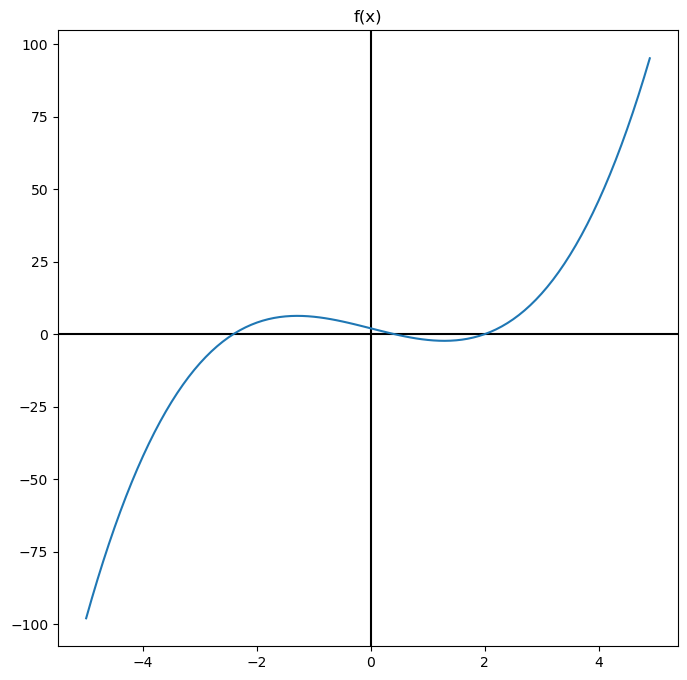

In [29]:
x_values = [x for x in np.arange(-5, 5, 0.1)]
f_values = [f(x) for x in np.arange(-5, 5, 0.1)]

plt.figure(figsize = (8, 8))

plt.axvline(x = 0, c = 'black') # Добавление оси ординат (ax vertical line)
plt.axhline(y = 0, c = 'black') # Добавление оси aбсцисс (ax vertical line)
plt.title('f(x)') # Добавление заголовка
plt.plot(x_values, f_values)
plt.show()

In [30]:
def grad_f(x): # Считаем градиент функции
    return 3 * (x ** 2) - 5

In [31]:
def gradient_descent(x_start, learning_rate, epsilon, num_iterations): # Алгоритм Градиентного Спуска
    x_curr = x_start
    for i in range(num_iterations):
        x_new = x_curr - learning_rate * grad_f(x_curr)
        if abs(x_new - x_curr) < epsilon:
            return x_curr
        x_curr = x_new
    return x_curr

In [32]:
x_res = gradient_descent(x_start = 5, learning_rate = 0.01, epsilon = 0.001, num_iterations = 10000)
x_res

1.303167415909252

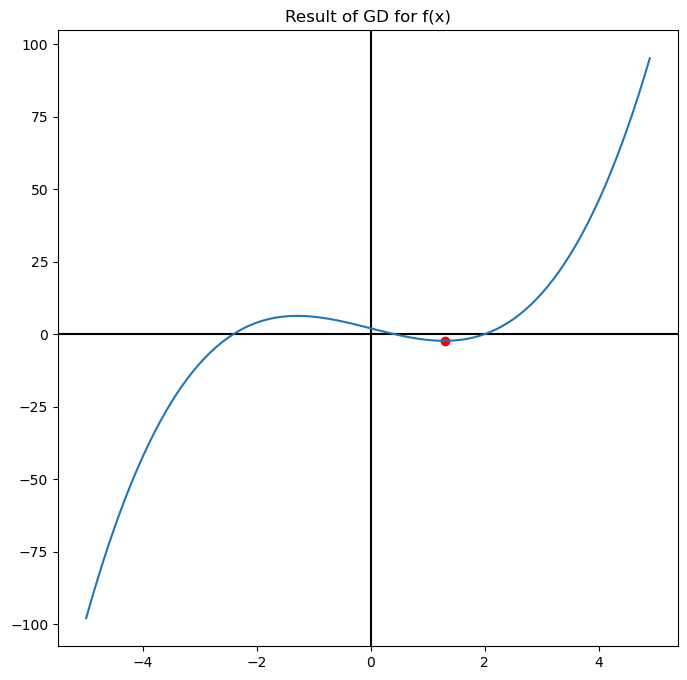

In [33]:
plt.figure(figsize = (8, 8))

plt.axvline(x = 0, c = 'black') # Добавление оси ординат (ax vertical line)
plt.axhline(y = 0, c = 'black') # Добавление оси aбсцисс (ax vertical line)
plt.title('Result of GD for f(x)') # Добавление заголовка
plt.plot(x_values, f_values)
plt.scatter(x_res, f(x_res), marker = 'o', c = 'red') # Добавление результата Градиентного спуска на график
plt.show()

# Градиентный спуск для функции нескольких переменных

In [62]:
import pandas as pd
import numpy as np
RANDOM_STATE = 42
rs = np.random.RandomState(RANDOM_STATE)

In [63]:
df = pd.DataFrame({'x1': [10, 5, 7], 'x2': [40, 36, 30], 'y': [100, 73, 71]})
df

,x1,x2,y
0,10,40,100
1,5,36,73
2,7,30,71


In [64]:
def prediction(w, x1, x2):
    return w[0] + w[1] * x1 + w[2] * x2

In [65]:
def grad_MSE(w, x1, x2, y):
    dwo = (2/3) * (w[0] + w[1] * x1 + w[2] * x2 - y)
    dw1 = (2/3) * x1 * (w[0] + w[1] * x1 + w[2] * x2 - y)
    dw2 = (2/3) * x2 * (w[0] + w[1] * x1 + w[2] * x2 - y)
    return np.array([dwo, dw1, dw2])

In [66]:
grad_MSE((1, 1, 1), 10, 40, 100)

array([  -32.66666667,  -326.66666667, -1306.66666667])

In [67]:
def gradient_descent(data, w_start, learning_rate, num_iterations): # Алгоритм Градиентного Спуска
    w_curr = w_start
    for i in range(num_iterations):
        GradMSE = np.zeros(3)
        for _, row in data.iterrows():
            x1, x2, y = row
            GradMSE += grad_MSE(w_curr, x1, x2, y)
        w_new = w_curr - learning_rate * GradMSE
        w_curr = w_new
    return w_curr

In [70]:
gradient_descent(df, np.random.rand(3), 0.0001, 5000)

array([0.51216601, 3.93684066, 1.47363536])

# Градиентный спуск в векторном виде

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

RANDOM_STATE = 42
np.random.RandomState(RANDOM_STATE)

RandomState(MT19937) at 0x2A48F4D5340

In [45]:
df = pd.DataFrame({'x1': [10, 5, 7], 'x2': [40, 36, 30], 'y': [100, 73, 71]})
df

,x1,x2,y
0,10,40,100
1,5,36,73
2,7,30,71


In [75]:
def compute_cost(X, y, theta): # MSE
    return (1. / len(y)) * (np.linalg.norm(X @ theta - y ) ** 2)

In [76]:
def gradient_descent(X, y, learning_rate, iterations):

    X = np.hstack((np.ones((X.shape[0], 1)), X)) # добавляем к Х столбец из 1
    params = np.random.rand(X.shape[1])

    m = X.shape[0]

    cost_track = np.zeros((iterations,1))

    for i in range(iterations):
        params = params - 2./m * learning_rate * (X.T @ ((X @ params) - y))
        cost_track[i] = compute_cost(X, y, params)

    return cost_track, params

In [77]:
def predict(X, params):
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    return X @ params

In [78]:
track, weights = gradient_descent(df[['x1','x2']], df['y'], 0.0001, 5000)

print(weights)

[0.52880691 3.97279935 1.46566909]


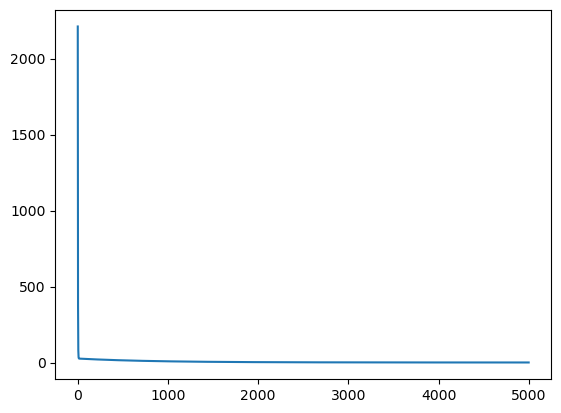

In [79]:
plt.plot(track)

# Линейная регрессия: аналитический и численный подходы

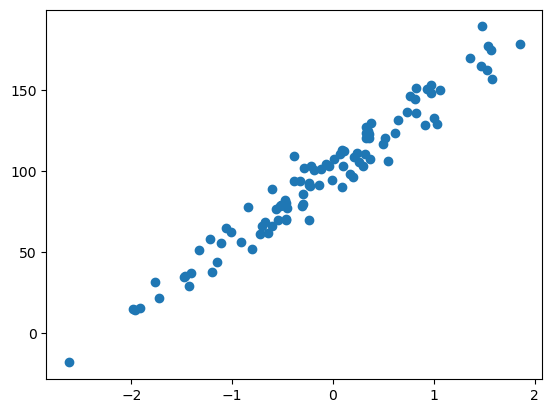

In [2]:
import numpy as np
from sklearn.datasets import make_regression
from matplotlib import pyplot as plt

RANDOM_STATE = 42
np.random.RandomState(RANDOM_STATE)

# Сгенерируем данные
X, y = make_regression(n_samples=100, n_features=1, random_state=RANDOM_STATE, noise=10.0, bias=100.0)

# Нарисуем данные
plt.scatter(X, y);

# Аналитический подход

r2: 0.9538252459635717


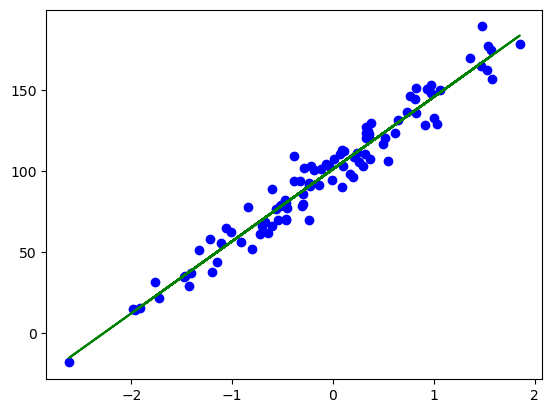

In [3]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)

pred_lr = lr.predict(X)

from sklearn.metrics import r2_score

plt.scatter(X, y, c='blue')
plt.plot(X, pred_lr, '-', c='green')

print('r2:',r2_score(y, pred_lr))

# Численный подход (Стохастический градиентный спуск)

r2: 0.9538237739950463


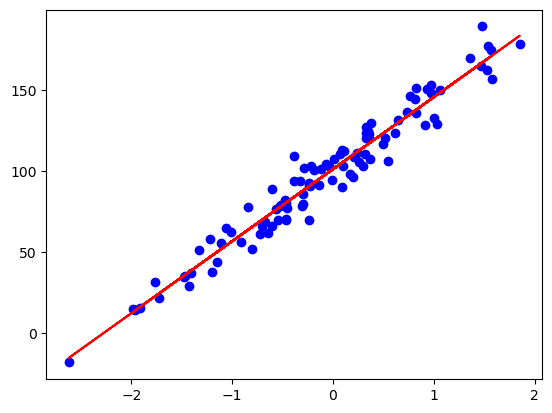

In [4]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor()
sgd.fit(X, y)

pred_sgd = sgd.predict(X)

plt.scatter(X, y, c='blue')
plt.plot(X, pred_sgd, '-', c='red')

print('r2:',r2_score(y, pred_sgd))

In [89]:
# Сравним качество предсказаний
print('r2 exact:  ',r2_score(y, pred_lr))
print('r2 numeric:',r2_score(y, pred_sgd)) 

r2 exact:   0.9538252459635717
r2 numeric: 0.9538248654215574


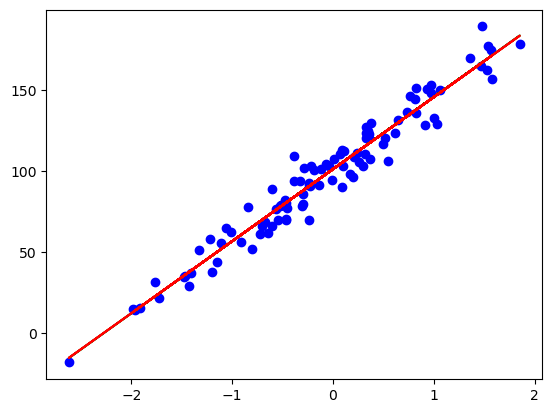

In [6]:
plt.scatter(X, y, c='blue')
plt.plot(X, pred_lr, '-', c='green')
plt.plot(X, pred_sgd, '-', c='red')

plt.show()